In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

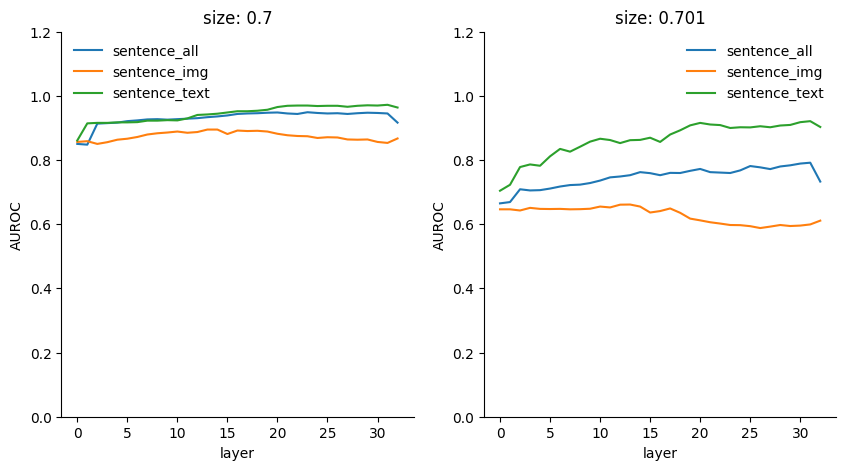

In [47]:
metric = 'auroc'
prompt_type = 'complex'
sizes = ['0.7', '0.701']
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(sizes),
    figsize=(5*len(sizes), 5)
)

for idx, size_ in enumerate(sizes):
    plot_df = pd.read_csv(f'./results/llava7B/linear_probing/probe_text/complex/probing_results_size_{size_}_3.csv', index_col=0)
    plot_df['embedding_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]

    b = sns.lineplot(
        data=plot_df[plot_df['embedding_over']=='sentence'],
        x='layer',
        y=metric,
        hue='embedding_level',
        ax=axs[idx]
    )
    # b.axhline(auprc_baseline, color='black', linestyle='--')
    b.set(ylim=(0,1.2))
    b.legend(frameon=False)
    b.set_ylabel(metric.upper())
    b.set_title(f"size: {size_}")



sns.despine(top=True, right=True)